# Sentinel-2 Water Mask Extraction (SCL + MNDWI)

### What this notebook does

1. Searches Sentinel-2 L2A imagery for a user-specified **date range** and **bounding box**
2. Reads the **SCL** (Scene Classification Layer) band — extracts water class (SCL == 6)
3. Reads **Green (B03)** and **SWIR1 (B11)** bands — computes **MNDWI** water mask
4. Exports both water masks as GeoTIFFs

### Why SCL instead of running Fmask from scratch?

Sentinel-2 L2A products include the **SCL (Scene Classification Layer)**, produced by ESA's
Sen2Cor processor. SCL classifies every pixel into water, cloud, cloud shadow, vegetation,
bare soil, etc. — this is functionally what Fmask does. Running `python-fmask` separately
would require downloading full granules (~800 MB each) and complex dependencies, only to
reproduce what SCL already provides. We use SCL as the **primary** water mask and additionally
compute **MNDWI** as a spectral-based detector — giving two independent Sentinel-2 water
references for future comparison.

### SCL class codes

| Code | Class | Code | Class |
|------|-------|------|-------|
| 0 | No Data | 6 | **Water** |
| 1 | Saturated/Defective | 7 | Cloud Low Prob. |
| 2 | Dark Area / Shadows | 8 | Cloud Medium Prob. |
| 3 | Cloud Shadows | 9 | Cloud High Prob. |
| 4 | Vegetation | 10 | Thin Cirrus |
| 5 | Bare Soils | 11 | Snow/Ice |

### Data source

**Element84 Earth Search** — Sentinel-2 L2A as Cloud-Optimized GeoTIFFs on AWS.  
No authentication required. Only the ROI pixels are read (no full scene download).

---
## 0. Imports and GDAL Configuration

In [1]:
import numpy as np
import os
import rasterio
from rasterio.windows import from_bounds
from rasterio.enums import Resampling
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from pystac_client import Client
from pyproj import Transformer
from datetime import datetime
import warnings
warnings.filterwarnings('ignore', category=rasterio.errors.NotGeoreferencedWarning)

# GDAL environment for efficient COG access over HTTP
os.environ['AWS_NO_SIGN_REQUEST'] = 'YES'
os.environ['GDAL_DISABLE_READDIR_ON_OPEN'] = 'EMPTY_DIR'
os.environ['CPL_VSIL_CURL_ALLOWED_EXTENSIONS'] = '.tif,.TIF'
os.environ['GDAL_HTTP_MERGE_CONSECUTIVE_RANGES'] = 'YES'

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

print("Imports OK.")

Imports OK.


---
## 1. Configuration — EDIT THIS SECTION

Define your region of interest and date range.

**Option A:** Specify the bounding box manually as `[west, south, east, north]` in lat/lon.  
**Option B:** Extract the bounding box from your CBERS-4 GeoTIFF automatically.

In [2]:
# =====================================================================
#  >>> EDIT THESE PARAMETERS <<<
# =====================================================================

# --- Date range (match your CBERS-4 acquisition) ---
DATE_START = "2025-03-15"
DATE_END   = "2026-03-15"

# --- Maximum cloud cover (%) ---
MAX_CLOUD_COVER = 25

# --- Region of Interest ---
# Option A: Manual bounding box [west, south, east, north] in EPSG:4326
BBOX = [
    -54.6300, # Oeste 
    -25.6500, # Sul 
    -54.4300, # Leste 
    -25.4200  # Norte
]   

# Option B: Extract from your CBERS-4 band file (uncomment below)
# CBERS4_REF_PATH = "../data/CBERS_4_WFI_20240101_000_000_L4_BAND13.tif"
# with rasterio.open(CBERS4_REF_PATH) as src:
#     transformer = Transformer.from_crs(src.crs, "EPSG:4326", always_xy=True)
#     left, bottom = transformer.transform(src.bounds.left, src.bounds.bottom)
#     right, top = transformer.transform(src.bounds.right, src.bounds.top)
#     BBOX = [left, bottom, right, top]
#     print(f"Extracted bbox from CBERS-4: {BBOX}")

# --- Output directory ---
OUTPUT_DIR = "C:/Users/xavie/cipc-data/raw/sentinel-2"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Date range:   {DATE_START} to {DATE_END}")
print(f"Cloud cover:  ≤ {MAX_CLOUD_COVER}%")
print(f"Bounding box: {BBOX}")
print(f"Output dir:   {OUTPUT_DIR}")

Date range:   2025-03-15 to 2026-03-15
Cloud cover:  ≤ 25%
Bounding box: [-54.63, -25.65, -54.43, -25.42]
Output dir:   C:/Users/xavie/cipc-data/raw/sentinel-2


---
## 2. Search Sentinel-2 L2A via STAC

In [3]:
STAC_ENDPOINT = "https://earth-search.aws.element84.com/v1"
COLLECTION = "sentinel-2-l2a"

catalog = Client.open(STAC_ENDPOINT)

search = catalog.search(
    collections=[COLLECTION],
    bbox=BBOX,
    datetime=f"{DATE_START}/{DATE_END}",
    query={"eo:cloud_cover": {"lt": MAX_CLOUD_COVER}},
    max_items=50,
)

items = list(search.items())
print(f"Found {len(items)} Sentinel-2 L2A scenes with cloud cover < {MAX_CLOUD_COVER}%")

if len(items) == 0:
    print("\n>>> No scenes found. Try widening the date range or cloud cover threshold.")

Found 36 Sentinel-2 L2A scenes with cloud cover < 25%


### 2.1 Display available scenes

In [4]:
print(f"{'#':>3}  {'Date':12s}  {'Cloud%':>7s}  {'Tile':6s}  {'ID'}")
print("-" * 80)

for i, item in enumerate(items):
    dt = item.datetime.strftime("%Y-%m-%d") if item.datetime else "N/A"
    cloud = item.properties.get("eo:cloud_cover", -1)
    tile = item.properties.get("s2:mgrs_tile", "?")
    print(f"{i:3d}  {dt:12s}  {cloud:6.1f}%  {tile:6s}  {item.id}")

print(f"\nSelect a scene index in the next cell (SCENE_INDEX).")

  #  Date           Cloud%  Tile    ID
--------------------------------------------------------------------------------
  0  2026-03-15      21.5%  ?       S2C_21JYM_20260315_1_L2A
  1  2026-03-15      21.5%  ?       S2C_21JYM_20260315_0_L2A
  2  2026-03-10      12.8%  ?       S2B_21JYM_20260310_0_L2A
  3  2026-02-08      10.9%  ?       S2B_21JYM_20260208_0_L2A
  4  2026-01-29      14.1%  ?       S2B_21JYM_20260129_0_L2A
  5  2026-01-24       6.0%  ?       S2C_21JYM_20260124_0_L2A
  6  2026-01-19       2.5%  ?       S2B_21JYM_20260119_0_L2A
  7  2026-01-14       3.8%  ?       S2C_21JYM_20260114_0_L2A
  8  2026-01-04       1.3%  ?       S2C_21JYM_20260104_0_L2A
  9  2025-12-20       0.0%  ?       S2B_21JYM_20251220_0_L2A
 10  2025-12-07       1.3%  ?       S2A_21JYM_20251207_0_L2A
 11  2025-12-05       0.4%  ?       S2C_21JYM_20251205_0_L2A
 12  2025-11-25       0.6%  ?       S2C_21JYM_20251125_0_L2A
 13  2025-11-20       0.0%  ?       S2B_21JYM_20251120_0_L2A
 14  2025-11-10       1.2%

---
## 3. Select Scene and Inspect Assets

In [5]:
# =====================================================================
#  >>> SELECT THE SCENE INDEX FROM THE TABLE ABOVE <<<
# =====================================================================
SCENE_INDEX = 3

item = items[SCENE_INDEX]
print(f"Selected: {item.id}")
print(f"Date:     {item.datetime}")
print(f"Cloud:    {item.properties.get('eo:cloud_cover', '?')}%")
print(f"CRS:      {item.properties.get('proj:epsg', '?')}")
print()
print("Available assets:")
for key in sorted(item.assets.keys()):
    asset = item.assets[key]
    print(f"  {key:15s} → {asset.href.split('/')[-1]}")

Selected: S2B_21JYM_20260208_0_L2A
Date:     2026-02-08 13:49:33.939000+00:00
Cloud:    10.946221%
CRS:      ?

Available assets:
  aot             → AOT.tif
  aot-jp2         → AOT.jp2
  blue            → B02.tif
  blue-jp2        → B02.jp2
  cloud           → CLD_20m.jp2
  coastal         → B01.tif
  coastal-jp2     → B01.jp2
  granule_metadata → granule_metadata.xml
  green           → B03.tif
  green-jp2       → B03.jp2
  nir             → B08.tif
  nir-jp2         → B08.jp2
  nir08           → B8A.tif
  nir08-jp2       → B8A.jp2
  nir09           → B09.tif
  nir09-jp2       → B09.jp2
  product_metadata → product_metadata.xml
  red             → B04.tif
  red-jp2         → B04.jp2
  rededge1        → B05.tif
  rededge1-jp2    → B05.jp2
  rededge2        → B06.tif
  rededge2-jp2    → B06.jp2
  rededge3        → B07.tif
  rededge3-jp2    → B07.jp2
  scl             → SCL.tif
  scl-jp2         → SCL.jp2
  snow            → SNW_20m.jp2
  swir16          → B11.tif
  swir16-jp2      → B1

---
## 4. Helper Function: Read Band Clipped to ROI

Reads only the pixels within the bounding box from the COG (no full download).

In [6]:
def read_band_in_bbox(item, asset_key, bbox_4326):
    """
    Read a single band from a Sentinel-2 STAC item, clipped to a bounding box.
    
    Parameters
    ----------
    item : pystac.Item
    asset_key : str — e.g., 'scl', 'green', 'swir16'
    bbox_4326 : list — [west, south, east, north] in EPSG:4326
    
    Returns
    -------
    data : np.ndarray — 2D array of pixel values
    profile : dict — rasterio profile for the windowed read
    """
    url = item.assets[asset_key].href
    west, south, east, north = bbox_4326
    
    with rasterio.open(url) as src:
        # Transform bbox from EPSG:4326 to the image CRS
        transformer = Transformer.from_crs(
            "EPSG:4326", src.crs, always_xy=True
        )
        img_left, img_bottom = transformer.transform(west, south)
        img_right, img_top = transformer.transform(east, north)
        
        # Compute the window in pixel coordinates
        window = from_bounds(
            img_left, img_bottom, img_right, img_top,
            src.transform
        )
        
        # Read only the windowed portion
        data = src.read(1, window=window)
        
        # Build profile for the output
        profile = src.profile.copy()
        profile.update(
            width=data.shape[1],
            height=data.shape[0],
            transform=src.window_transform(window),
        )
    
    return data, profile

print("Helper function defined.")

Helper function defined.


---
## 5. Read SCL Band and Extract Water Mask

In [7]:
print("Reading SCL band (20 m resolution)...")
scl, scl_profile = read_band_in_bbox(item, "scl", BBOX)
print(f"  Shape: {scl.shape}")
print(f"  CRS:   {scl_profile['crs']}")

# Extract water mask: SCL == 6 is water
scl_water = (scl == 6).astype(np.uint8)

# Also identify clouds and shadows for reference
scl_cloud  = np.isin(scl, [8, 9, 10]).astype(np.uint8)
scl_shadow = (scl == 3).astype(np.uint8)
scl_nodata = (scl == 0).astype(np.uint8)

n_total = scl.size - scl_nodata.sum()
print(f"\nSCL classification (valid pixels: {n_total:,d}):")
scl_classes = {
    0: "No Data", 1: "Saturated", 2: "Dark Area", 3: "Cloud Shadow",
    4: "Vegetation", 5: "Bare Soil", 6: "WATER", 7: "Cloud Low",
    8: "Cloud Medium", 9: "Cloud High", 10: "Cirrus", 11: "Snow/Ice"
}
for code, name in scl_classes.items():
    count = np.sum(scl == code)
    if count > 0:
        pct = 100.0 * count / max(n_total, 1)
        marker = " ◄" if code == 6 else ""
        print(f"  {code:2d} {name:15s}: {count:>10,d} px  ({pct:5.2f}%){marker}")

Reading SCL band (20 m resolution)...
  Shape: (1256, 1029)
  CRS:   EPSG:32721

SCL classification (valid pixels: 1,292,424):
   2 Dark Area      :      2,548 px  ( 0.20%)
   3 Cloud Shadow   :    142,815 px  (11.05%)
   4 Vegetation     :    491,886 px  (38.06%)
   5 Bare Soil      :    348,035 px  (26.93%)
   6 WATER          :     62,185 px  ( 4.81%) ◄
   7 Cloud Low      :     10,887 px  ( 0.84%)
   8 Cloud Medium   :    133,067 px  (10.30%)
   9 Cloud High     :    100,988 px  ( 7.81%)
  10 Cirrus         :         13 px  ( 0.00%)


### 5.1 Visualize SCL

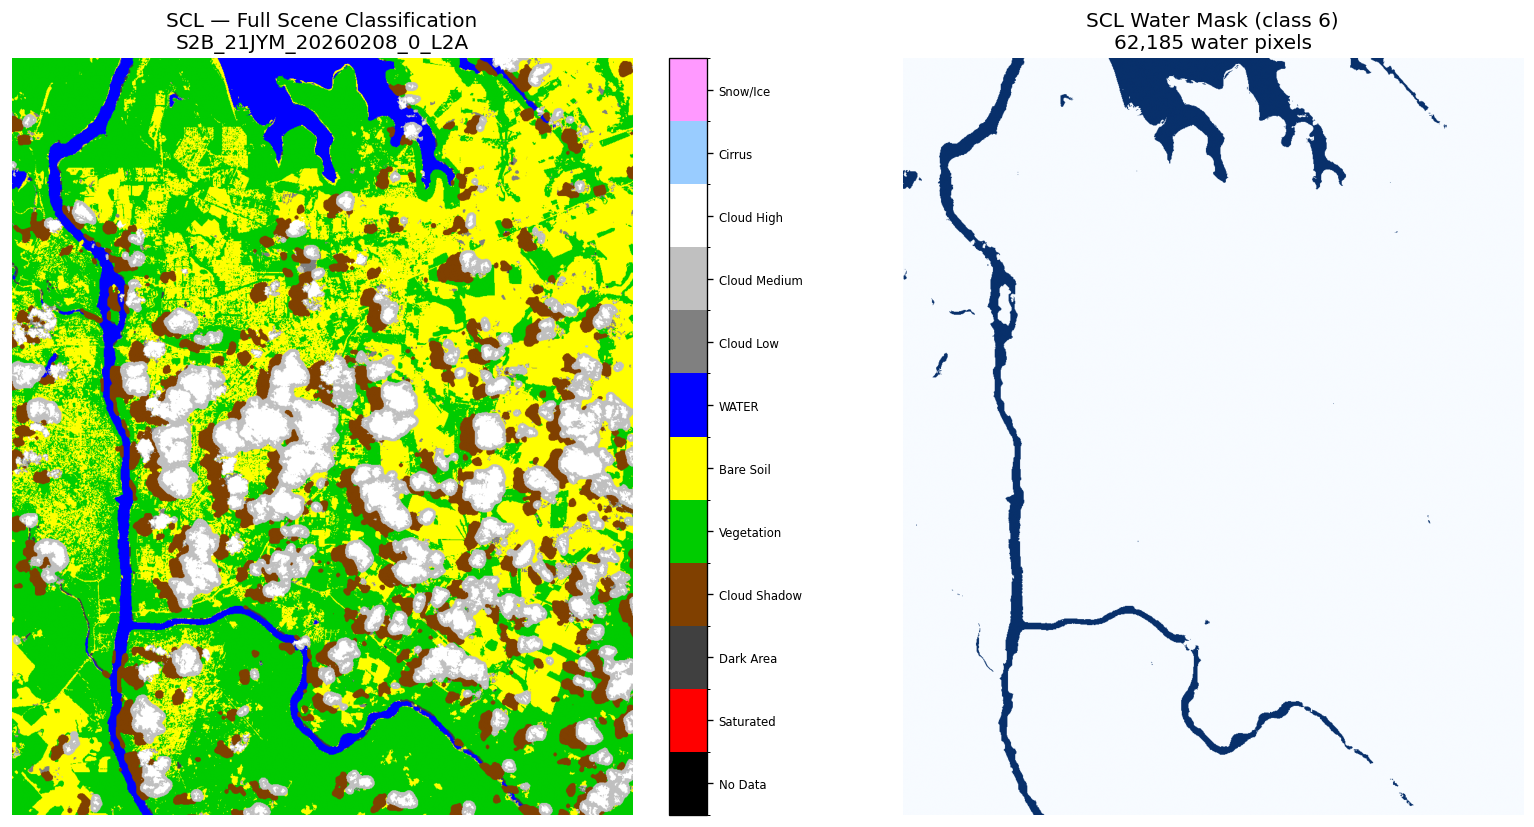

In [8]:
# SCL color map (ESA standard)
scl_colors = [
    "#000000",  # 0  No Data
    "#ff0000",  # 1  Saturated
    "#404040",  # 2  Dark area
    "#804000",  # 3  Cloud shadow
    "#00cc00",  # 4  Vegetation
    "#ffff00",  # 5  Bare soil
    "#0000ff",  # 6  Water
    "#808080",  # 7  Cloud low
    "#c0c0c0",  # 8  Cloud medium
    "#ffffff",  # 9  Cloud high
    "#99ccff",  # 10 Cirrus
    "#ff99ff",  # 11 Snow
]
scl_cmap = ListedColormap(scl_colors)
scl_norm = BoundaryNorm(np.arange(-0.5, 12.5, 1), scl_cmap.N)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: Full SCL
im0 = axes[0].imshow(scl, cmap=scl_cmap, norm=scl_norm)
axes[0].set_title(f"SCL — Full Scene Classification\n{item.id}")
axes[0].axis("off")
cbar = fig.colorbar(im0, ax=axes[0], ticks=range(12), fraction=0.046, pad=0.04)
cbar.ax.set_yticklabels([scl_classes.get(i, "") for i in range(12)], fontsize=7)

# Right: Water only
water_vis = scl_water.astype(float)
water_vis[scl == 0] = np.nan
axes[1].imshow(water_vis, cmap="Blues", vmin=0, vmax=1)
axes[1].set_title(f"SCL Water Mask (class 6)\n{scl_water.sum():,d} water pixels")
axes[1].axis("off")

fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "01_scl_water_mask.png"), dpi=150)
plt.show()

---
## 6. Compute MNDWI Water Mask

**MNDWI = (Green − SWIR1) / (Green + SWIR1)**

- Green = B03 (10 m resolution)
- SWIR1 = B11 (20 m resolution)

Water has MNDWI > 0 (Green reflectance exceeds SWIR1).  
This index is unavailable for WFI sensors (no SWIR band), which is why Sentinel-2 is valuable.

In [9]:
print("Reading Green band (B03, 10 m)...")
green, green_profile = read_band_in_bbox(item, "green", BBOX)
print(f"  Shape: {green.shape}")

print("Reading SWIR1 band (B11, 20 m)...")
swir16, swir16_profile = read_band_in_bbox(item, "swir16", BBOX)
print(f"  Shape: {swir16.shape}")

# Resample SWIR1 (20 m) to match Green (10 m) resolution
# by re-reading with the target shape
if green.shape != swir16.shape:
    print(f"\nResampling SWIR1 from {swir16.shape} to {green.shape}...")
    url_swir = item.assets["swir16"].href
    west, south, east, north = BBOX
    
    with rasterio.open(url_swir) as src:
        transformer = Transformer.from_crs("EPSG:4326", src.crs, always_xy=True)
        img_left, img_bottom = transformer.transform(west, south)
        img_right, img_top = transformer.transform(east, north)
        window = from_bounds(img_left, img_bottom, img_right, img_top, src.transform)
        
        swir16 = src.read(
            1, window=window,
            out_shape=green.shape,
            resampling=Resampling.bilinear
        )
    print(f"  Resampled SWIR1 shape: {swir16.shape}")

print("\nBands loaded.")

Reading Green band (B03, 10 m)...
  Shape: (2511, 2058)
Reading SWIR1 band (B11, 20 m)...
  Shape: (1256, 1029)

Resampling SWIR1 from (1256, 1029) to (2511, 2058)...
  Resampled SWIR1 shape: (2511, 2058)

Bands loaded.


In [10]:
# Compute MNDWI
green_f = green.astype(np.float64)
swir16_f = swir16.astype(np.float64)

denominator = green_f + swir16_f
mndwi = np.where(denominator > 0, (green_f - swir16_f) / denominator, 0)

# Water mask: MNDWI > 0
mndwi_water = (mndwi > 0).astype(np.uint8)

# Mask out nodata (where both bands are 0)
nodata = (green == 0) & (swir16 == 0)
mndwi_water[nodata] = 255
mndwi[nodata] = np.nan

n_mndwi_water = np.sum(mndwi_water == 1)
n_valid_mndwi = np.sum(~nodata)
print(f"MNDWI water pixels: {n_mndwi_water:,d} ({100*n_mndwi_water/max(n_valid_mndwi,1):.2f}%)")

MNDWI water pixels: 355,061 (6.87%)


### 6.1 Visualize MNDWI

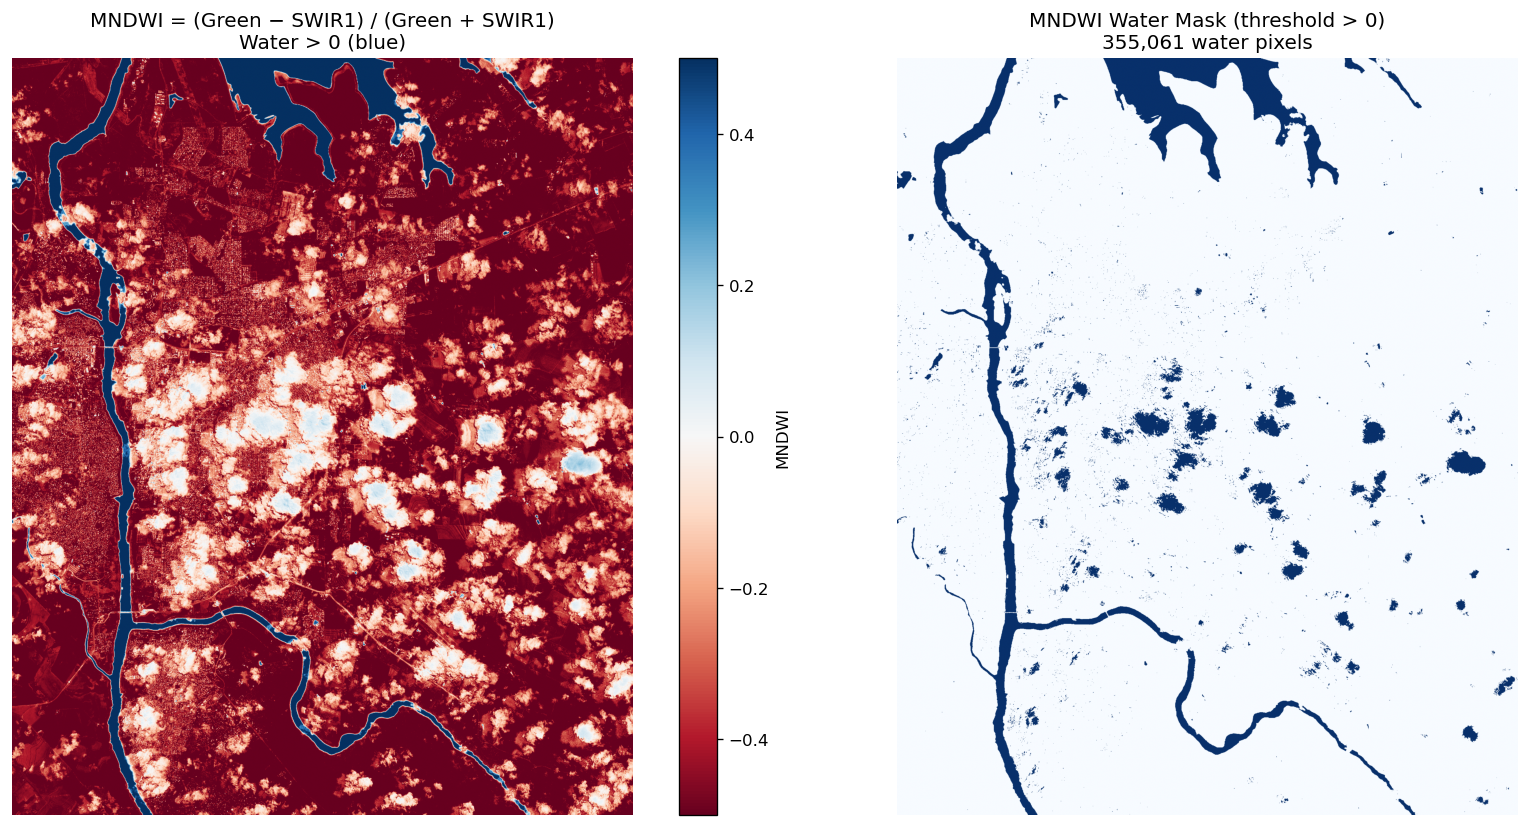

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: MNDWI continuous
im0 = axes[0].imshow(mndwi, cmap="RdBu", vmin=-0.5, vmax=0.5)
axes[0].set_title("MNDWI = (Green − SWIR1) / (Green + SWIR1)\nWater > 0 (blue)")
axes[0].axis("off")
fig.colorbar(im0, ax=axes[0], label="MNDWI", fraction=0.046)

# Right: MNDWI binary water mask
mndwi_vis = mndwi_water.astype(float)
mndwi_vis[mndwi_water == 255] = np.nan
axes[1].imshow(mndwi_vis, cmap="Blues", vmin=0, vmax=1)
axes[1].set_title(f"MNDWI Water Mask (threshold > 0)\n{n_mndwi_water:,d} water pixels")
axes[1].axis("off")

fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "02_mndwi_water_mask.png"), dpi=150)
plt.show()

---
## 7. Compare SCL vs MNDWI Water Masks

SCL vs MNDWI agreement:
  Both detect water:         222,368 pixels
  MNDWI only:                132,693 pixels
  SCL only:                   25,732 pixels
  Neither (non-water):     4,786,845 pixels


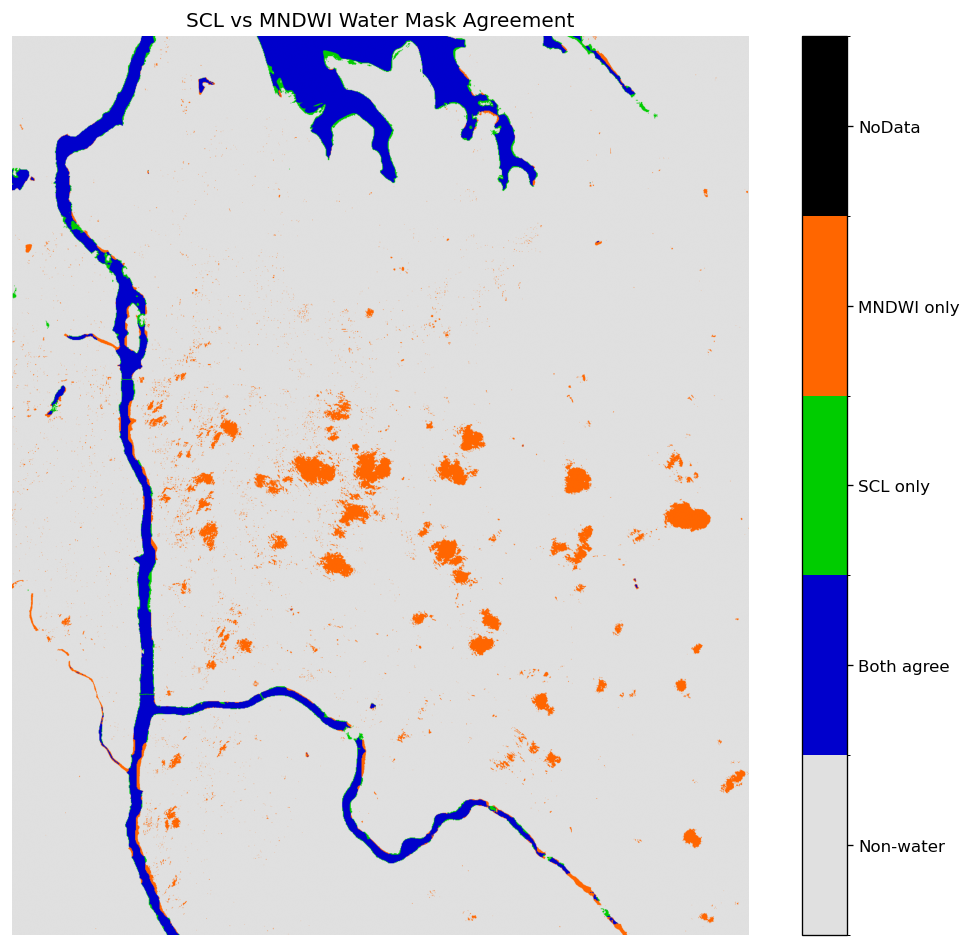

In [12]:
# Resample SCL water mask (20 m) to MNDWI grid (10 m) for comparison
if scl_water.shape != mndwi_water.shape:
    from scipy.ndimage import zoom
    scale_y = mndwi_water.shape[0] / scl_water.shape[0]
    scale_x = mndwi_water.shape[1] / scl_water.shape[1]
    scl_water_10m = zoom(scl_water, (scale_y, scale_x), order=0)  # nearest neighbor
    # Ensure same shape (rounding)
    scl_water_10m = scl_water_10m[:mndwi_water.shape[0], :mndwi_water.shape[1]]
else:
    scl_water_10m = scl_water

# Agreement analysis
valid_both = ~nodata & (scl_water_10m < 255)
mndwi_w = (mndwi_water == 1) & valid_both
scl_w   = (scl_water_10m == 1) & valid_both

both_water    = mndwi_w & scl_w
mndwi_only    = mndwi_w & ~scl_w
scl_only      = scl_w & ~mndwi_w
neither       = ~mndwi_w & ~scl_w & valid_both

print("SCL vs MNDWI agreement:")
print(f"  Both detect water:    {both_water.sum():>12,d} pixels")
print(f"  MNDWI only:           {mndwi_only.sum():>12,d} pixels")
print(f"  SCL only:             {scl_only.sum():>12,d} pixels")
print(f"  Neither (non-water):  {neither.sum():>12,d} pixels")

# Visual comparison
comparison = np.zeros(mndwi_water.shape, dtype=np.uint8)
comparison[neither]    = 0  # Non-water
comparison[both_water] = 1  # Both agree: water
comparison[scl_only]   = 2  # SCL only
comparison[mndwi_only] = 3  # MNDWI only
comparison[nodata]     = 4  # NoData

fig, ax = plt.subplots(figsize=(10, 8))
cmap_comp = ListedColormap(["#e0e0e0", "#0000cc", "#00cc00", "#ff6600", "#000000"])
norm_comp = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5, 4.5], cmap_comp.N)
im = ax.imshow(comparison, cmap=cmap_comp, norm=norm_comp)
ax.set_title("SCL vs MNDWI Water Mask Agreement")
ax.axis("off")
cbar = fig.colorbar(im, ax=ax, ticks=[0, 1, 2, 3, 4], fraction=0.046)
cbar.ax.set_yticklabels(["Non-water", "Both agree", "SCL only", "MNDWI only", "NoData"])
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "03_scl_vs_mndwi.png"), dpi=150)
plt.show()

---
## 8. Export Water Masks as GeoTIFFs

In [13]:
scene_date = item.datetime.strftime("%Y%m%d") if item.datetime else "unknown"

# --- SCL water mask (20 m) ---
scl_out_path = os.path.join(OUTPUT_DIR, f"s2_scl_water_{scene_date}.tif")
scl_out_profile = scl_profile.copy()
scl_out_profile.update(dtype=rasterio.uint8, count=1, nodata=255, compress="lzw")

scl_water_out = scl_water.copy()
scl_water_out[scl == 0] = 255  # NoData

with rasterio.open(scl_out_path, "w", **scl_out_profile) as dst:
    dst.write(scl_water_out, 1)
print(f"SCL water mask saved:   {scl_out_path}")

# --- MNDWI water mask (10 m) ---
mndwi_out_path = os.path.join(OUTPUT_DIR, f"s2_mndwi_water_{scene_date}.tif")
mndwi_out_profile = green_profile.copy()
mndwi_out_profile.update(dtype=rasterio.uint8, count=1, nodata=255, compress="lzw")

with rasterio.open(mndwi_out_path, "w", **mndwi_out_profile) as dst:
    dst.write(mndwi_water, 1)
print(f"MNDWI water mask saved: {mndwi_out_path}")

print(f"\nEncoding: 0 = non-water, 1 = water, 255 = nodata")
print(f"\nThese GeoTIFFs are georeferenced and can be compared")
print(f"with the CBERS-4 Namikawa water mask after reprojection.")

SCL water mask saved:   C:/Users/xavie/cipc-data/raw/sentinel-2\s2_scl_water_20260208.tif
MNDWI water mask saved: C:/Users/xavie/cipc-data/raw/sentinel-2\s2_mndwi_water_20260208.tif

Encoding: 0 = non-water, 1 = water, 255 = nodata

These GeoTIFFs are georeferenced and can be compared
with the CBERS-4 Namikawa water mask after reprojection.


---
## 9. Summary

### What was produced:

| File | Resolution | Method | Description |
|------|-----------|--------|-------------|
| `s2_scl_water_YYYYMMDD.tif` | 20 m | SCL class 6 | Sen2Cor scene classification |
| `s2_mndwi_water_YYYYMMDD.tif` | 10 m | MNDWI > 0 | Spectral index (Green vs SWIR1) |

### Next steps (future notebook):

1. **Reproject** the CBERS-4 Namikawa water mask to the Sentinel-2 grid (or vice versa)
2. **Resample** to a common resolution (e.g., 64 m to match WFI)
3. Compute **confusion matrix** (TP, FP, FN, TN) using Sentinel-2 as reference
4. Calculate **accuracy metrics** (OA, Kappa, F1, Producer's/User's accuracy)